## Develop logistic Regression model for a given dataset.

C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


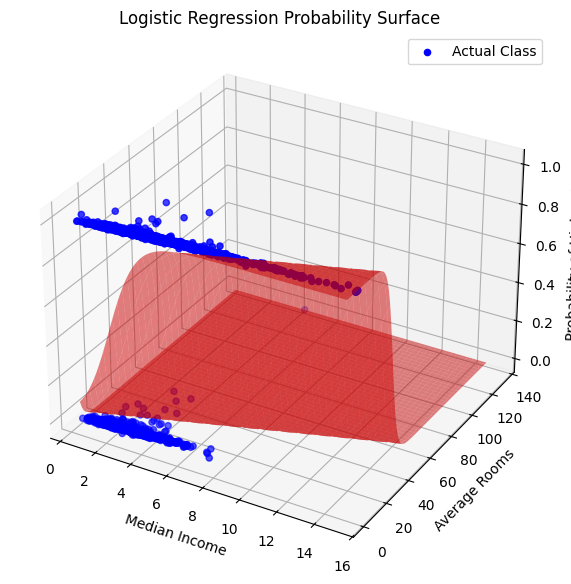

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_california_housing
import pandas as pd

california = fetch_california_housing()
x = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

x = x[['MedInc', 'AveRooms']]

median_value = np.median(y)
y_class = (y > median_value).astype(int)  

x_train, x_test, y_train, y_test = train_test_split(x, y_class, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_prob = model.predict_proba(x_test)[:,1]  

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_test['MedInc'], x_test['AveRooms'], y_test, color='blue', label='Actual Class')

x1_range = np.linspace(x_test['MedInc'].min(), x_test['MedInc'].max(), 100)
x2_range = np.linspace(x_test['AveRooms'].min(), x_test['AveRooms'].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
z = model.predict_proba(grid_points)[:,1].reshape(x1_grid.shape)

ax.plot_surface(x1_grid, x2_grid, z, color='red', alpha=0.5)


ax.set_xlabel('Median Income')
ax.set_ylabel('Average Rooms')
ax.set_zlabel('Probability of High Value')
ax.set_title('Logistic Regression Probability Surface')

ax.legend()
plt.show()